:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`custom_callbacks_and_termination.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Stopping on convergence and custom callbacks

We have already seen how callbacks can be used for monitoring a test loss.
In the [basics section](./stochastic_fit.md) the loss was still decaying when we stopped training, indicating that further training is necessary to reach the optimal parameters.

Here, we will show how to write custom callbacks and use them to stop optimization once convergence is reached.

In [2]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns

import nemos as nmo
from nemos._documentation_utils._stochastic_optim_toy_data import (
    DEFAULT_NWB_PATH,
    _simulate_and_write_to_disk,
)
from nemos._documentation_utils.plotting import plot_loss_history

jax.config.update("jax_enable_x64", True)
nap.nap_config.suppress_conversion_warnings = True
np.random.seed(123)

First, quickly set up and run a stochastic fit for 10 passes:

<Axes: xlabel='Log index (~batch index)', ylabel='Loss value'>

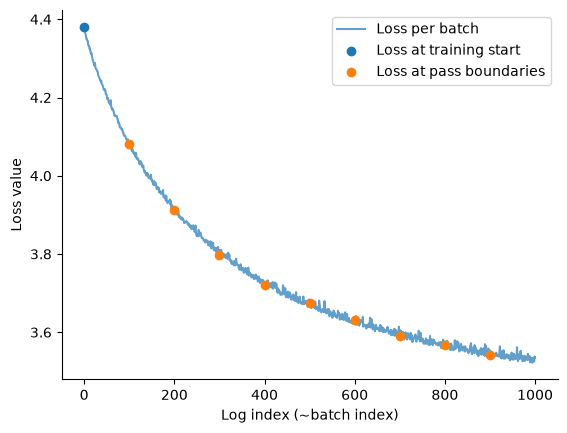

In [3]:
_simulate_and_write_to_disk()
data = nap.load_file(DEFAULT_NWB_PATH)
X, spike_trains = data["X"], data["spike_trains"]

loader = nmo.batching.LazyArrayDataLoader(
    X,
    spike_trains,
    batch_size=100,
)

batch_logger = nmo.callbacks.TestLossLogger(
    X,
    spike_trains,
    events={"train_begin", "batch_end"},
)

glm = nmo.glm.PopulationGLM(
    solver_name="GradientDescent",
    regularizer="Ridge",
    regularizer_strength=0.01,
    solver_kwargs={"stepsize": 0.05, "acceleration": False},
)

glm.stochastic_fit(loader, n_passes=10, callbacks=batch_logger)

plot_loss_history(batch_logger.loss_history)

## Create a custom callback for early stopping

Instead of guessing how many passes we need, undershooting and restarting, or overshooting and waiting too long, we can use callbacks to run optimization until convergence.

As mentioned before, to monitor training progress and the optimization's state during the fitting run, NeMoS has a callback system, allowing to execute custom code on the following events:
- beginning and end of training
- before and after each pass
- before and after each batch

### Define `EarlyStoppingCallback`

We define a custom callback that requests a stop based on the loss evaluated on a test set if it hasn't improved much for a given number of passes through the data.

Custom callbacks should inherit from [`Callback`](nemos.callbacks.Callback) and overwrite the required methods. In the current example we will implement `on_pass_end` to evaluate the loss after every pass.

Information is passed to callbacks through a [`TrainingContext`](nemos.callbacks.TrainingContext) object, which carries information about the state of the training such as the solver state, the current parameters, and the current pass and batch indices.
For convenience, the model being fit is also added to the context.

Requesting a stop of the optimization can be done by calling `ctx.request_stop()`.

In [4]:
class EarlyStoppingCallback(nmo.callbacks.Callback):
    """
    Stop training when test loss stops improving.

    Evaluates ``model.compute_loss(params, X_test, y_test)`` at the end of each pass.
    If the loss does not improve by at least ``min_delta`` for
    ``patience`` consecutive passes through the data, requests an early stop.

    Parameters
    ----------
    X_test :
        Test input data.
    y_test :
        Test target data.
    patience :
        Number of passes with no improvement before stopping.
    min_delta :
        Minimum decrease in loss to count as an improvement.
    """

    def __init__(self, X_test, y_test, patience=5, min_delta=0.0):
        self.X_test = X_test
        self.y_test = y_test
        self.patience = patience
        self.min_delta = min_delta

        self._ref_loss = np.inf
        self._wait = 0

    def on_pass_end(self, ctx: nmo.callbacks.TrainingContext) -> None:
        """Check whether test loss has improved and request stop if patience exceeded."""
        current_loss = ctx.model.compute_loss(
            (ctx.params.coef, ctx.params.intercept),
            self.X_test,
            self.y_test,
        )

        if current_loss < self._ref_loss - self.min_delta:
            self._ref_loss = current_loss
            self._wait = 0
        else:
            self._wait += 1
            if self._wait >= self.patience:
                ctx.request_stop(
                    f"Loss improved by less than {self.min_delta} for {self.patience} consecutive passes through the data (training epochs).\n"
                    f"last loss: {current_loss:.6f}\n"
                    f"reference loss: {self._ref_loss:.6f}\n"
                )

:::{tip}
Convergence can be defined in multiple ways, loss on a test set is just one of them.
\
NeMoS provides a [`SolverConvergenceCallback`](nemos.callbacks.SolverConvergenceCallback)
which evaluates the solver's own convergence criterion defined as its
`stochastic_convergence_criterion`. For built-in solvers this means
examining the change in parameter values at the end of each pass.
:::

:::{tip}
Some solvers evaluate and save the loss on each batch's data. This can be
accessed via `ctx.state.stats.function_val`.
:::

:::{caution}
Using `model.score` would require setting the model parameters and, for
some observation models, estimating the scale. Without these you would get
inaccurate scores, and for large data this is a lot of computation, so it
is not recommended -- just use `compute_loss` instead.
:::

### Configure the callback object

To avoid running for too long in this demo, we set `min_delta` relatively high. In practice you want to set this to a level that represents no true improvement.

In [5]:
early_stopping = EarlyStoppingCallback(X, spike_trains, patience=5, min_delta=0.02)

## Run the optimization until convergence

Multiple callbacks serving different functions can be used simultaneously by passing them as a `list` or [`CallbackList`](nemos.callbacks.CallbackList) to [`stochastic_fit`](nemos.glm.PopulationGLM.stochastic_fit).
Here, we continue logging the loss and add the early stopping callback:

In [6]:
glm.stochastic_fit(
    loader,
    # set n_passes very high, so stopping has to be triggered by the callback
    n_passes=10_000,
    init_params=glm.get_model_params(),
    callbacks=[batch_logger, early_stopping],
)

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7fbb581f04a0>
,regularizer,Ridge()
,regularizer_strength,0.01
,fix_params,"(None, ...)"
,solver_name,'GradientDescent'
,solver_kwargs,"{'acceleration': False, 'stepsize': 0.05}"
,fit_intercept,True
,feature_mask,None
Name,Type,Value
aux_,NoneType,None


Plotting the loss shows how the loss is starting to plateau:

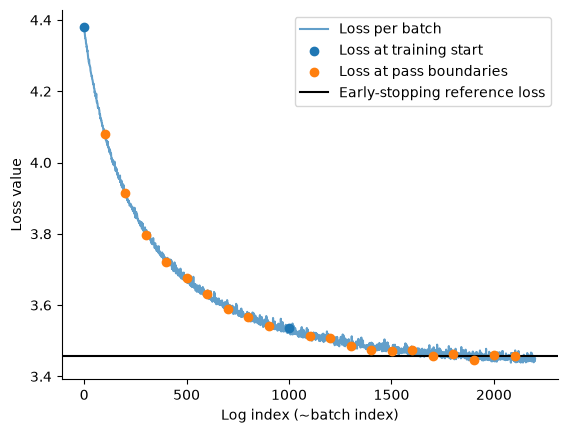

In [7]:
ax = plot_loss_history(batch_logger.loss_history)
ax.axhline(
    early_stopping._ref_loss,
    color="black",
    label="Early-stopping reference loss",
)
ax.legend()

In [8]:
# save image for thumbnail
import os
from pathlib import Path

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
    path = Path(root) / "html/_static/thumbnails/how_to_guide"
# if local store in ../_build/html/...
else:
    path = Path("../../_build/html/_static/thumbnails/how_to_guide")

# make sure the folder exists if run from build
if root or Path("../../assets/stylesheets").exists():
    path.mkdir(parents=True, exist_ok=True)

if path.exists():
    fig = ax.get_figure()
    fig.savefig(path / "batch_glm_loss_curve.svg")

After the fit, the model exposes a [`StochasticFitSummary`](nemos.callbacks.StochasticFitSummary)
through ``stochastic_fit_summary_``. This can, for example, be used to inspect why the run stopped:

In [9]:
print(glm.stochastic_fit_summary_.stop_reason)

Loss improved by less than 0.02 for 5 consecutive passes through the data (training epochs).
last loss: 3.448719
reference loss: 3.457883



## Evaluate result

Since this example is small enough, we can fit the full model until convergence and compare the results.

:::{warning}
In this section, calling ``score()`` after ``stochastic_fit()`` works because the example uses a Poisson ``PopulationGLM``, whose scale does not need to be estimated from the data after fitting.
Support for models that require post-hoc estimation of residual degrees of freedom and scale is still in progress.
:::

In [10]:
full_model = nmo.glm.PopulationGLM(regularizer="Ridge", regularizer_strength=0.01).fit(
    X, spike_trains
)

Now that the full model is fitted, we score the full model and the batch model against the full dataset using pseudo-R2:

In [11]:
full_scores = full_model.score(
    X,
    spike_trains,
    aggregate_sample_scores=lambda x: np.mean(x, axis=0),
    score_type="pseudo-r2-McFadden",
)
batch_scores = glm.score(
    X,
    spike_trains,
    aggregate_sample_scores=lambda x: np.mean(x, axis=0),
    score_type="pseudo-r2-McFadden",
)

full_scores = np.array(full_scores)
batch_scores = np.array(batch_scores)

We can also take a look at the coefficients.
Here we extract the weight matrix of shape `(n_neurons*n_basis, n_neurons)`
and reshape it to `(n_neurons, n_basis, n_neurons)`.
We then average along basis to get a weight matrix of shape `(n_neurons, n_neurons)`.

Let's compare scores for each neuron as well as the coefficients:

[Text(0.5, 1.0, 'Full model'), Text(0.5, 0, 'Neuron')]

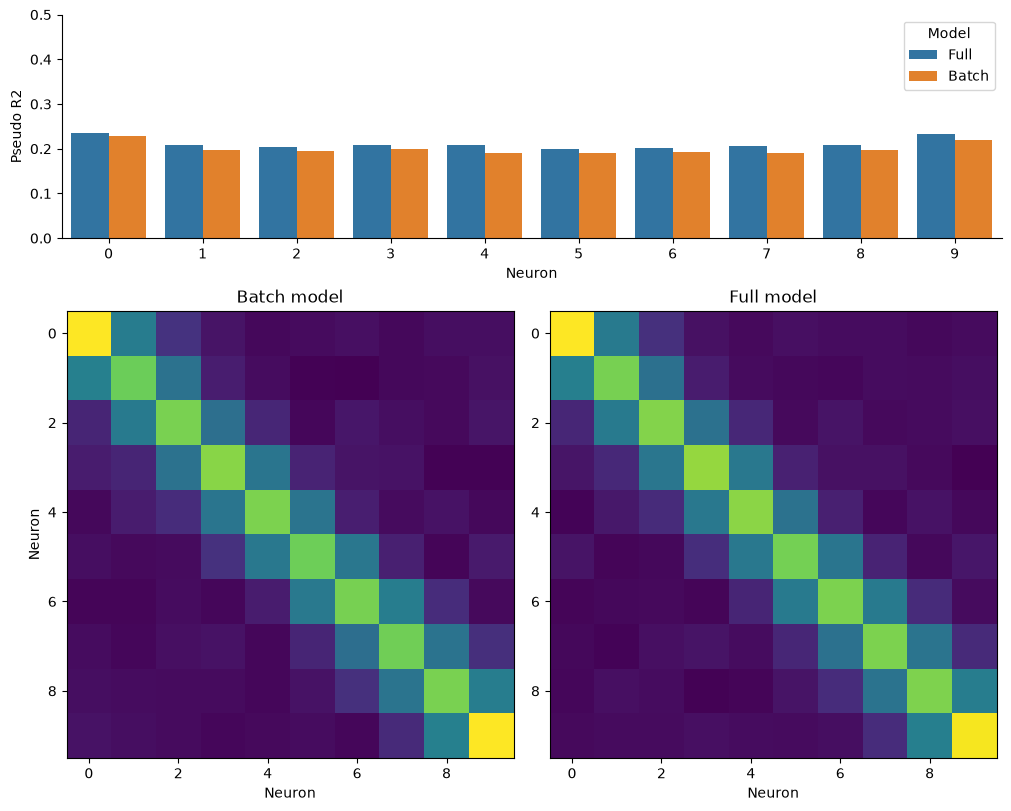

In [12]:
n_neurons = len(data["units"])
Wm = np.mean(np.abs(glm.coef_.reshape(n_neurons, -1, n_neurons)), 1)
Wm2 = np.mean(np.abs(full_model.coef_.reshape(n_neurons, -1, n_neurons)), 1)

score_df = pd.DataFrame(
    [(i, sc, "Full") for i, sc in enumerate(full_scores)]
    + [(i, sc, "Batch") for i, sc in enumerate(batch_scores)],
    columns=("Neuron", "Pseudo R2", "Model"),
)

fig = plt.figure(figsize=(10, 8), constrained_layout=True)
gs = fig.add_gridspec(3, 2)

ax_scores = fig.add_subplot(gs[0, :])
sns.barplot(x="Neuron", y="Pseudo R2", hue="Model", data=score_df)
ax_scores.set_ylim(0, 0.5)
sns.despine(ax=ax_scores)

ax_batch = fig.add_subplot(gs[1:, 0])
ax_batch.imshow(Wm)
ax_batch.set(title="Batch model", xlabel="Neuron", ylabel="Neuron")

ax_full = fig.add_subplot(gs[1:, 1])
ax_full.imshow(Wm2)
ax_full.set(title="Full model", xlabel="Neuron")

As we can see, the batch model starts to approximate the full model.